# **Model 1: AutoRegressive-MovingAverage Model**

(Given the copies of plots in the markdown, if it's not visible in git or editors)

I am fitting the ARMA/ARIMA baseline model, where I will make the price series stationary using differencing, and then fit the model on it using conditional sum of squares. Then, I will pick (p,d,q) by AIC with the given grid values, then will do residual diagnostics. Finally, I will be making forecasts for 24 months with a 95% confidence interval using Monte-Carlo simulation.

## **ARMA/ARIMA - theoritical explanation**

ARMA models are built for stationary series. The oil prices usually drift over time, so I did differencing on the series to remove the stochastic trend.

Let $y_t$ be the oil price time series. The differencing operator is,

* First Difference

$$
\Delta y_t = y_t - y_{t-1}
$$

* Second Difference

$$
\Delta^2 y_t = \Delta(\Delta y_t) = y_t - 2y_{t-1} + y_{t-2}
$$


After differencing $d$ times, I modelled the stationary series:

$$
x_t = \Delta^d y_t
$$

An ARMA ($p,q$) model describes a stationary series $x_t$ using, autoregressive that depends on the past values of $x$ and a moving average that depends on past forecast errors. The model is,

$$
x_t = c + \sum_{i=1}^{p} \phi_i x_{t-i} + \varepsilon_t
      + \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$

where, $c$ is a constant term (intercept), $\phi_i$ are the autoregressive (AR) coefficients, $\theta_j$ are the moving average (MA) coefficients, and $\varepsilon_t$ is the innovation (random shock), typically assumed to be white noise with:

$$
\mathbb{E}[\varepsilon_t] = 0
$$

$$
\mathrm{Var}(\varepsilon_t) = \sigma^2
$$

$$
\mathrm{Cov}(\varepsilon_t, \varepsilon_{t-k}) = 0 \quad \text{for } k \neq 0
$$

This is where ARIMA comes in where it combines ARMA and the differencing,

$$
\Delta^d y_t =
c
+ \sum_{i=1}^{p} \phi_i \Delta^d y_{t-i}
+ \varepsilon_t
+ \sum_{j=1}^{q} \theta_j \varepsilon_{t-j}
$$


The flow usually goes like, first choose $d$  to select the number of differences required to make the series stationary. Then, fit ARMA$(p, q)$ on the stationary series,

   $$
   x_t = \Delta^d y_t
   $$

Produce forecasts in the differenced space,

   $$
   x_{t+h}
   $$

Then, do invert differencing to transform forecasts back to price levels,

   $$
   y_{t+h}
   $$

## **Imports**

In [ ]:
import os
import numpy as np
import pandas as pd
from pathlib import Path
from scipy.optimize import minimize
from joblib import Parallel, delayed
import pickle
import warnings
warnings.filterwarnings("ignore")

import plotly.graph_objects as go
import plotly.express as px

from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.metrics import mean_squared_error

try:
    from numba import njit
    NUMBA_OK = True
except Exception:
    NUMBA_OK = False

## **Loading the data**

In [ ]:
df = pd.read_csv('/content/drive/MyDrive/oil_prices_2426.csv')
df["date"] = pd.to_datetime(df["date"], dayfirst=True)
df = df.sort_values("date").set_index("date")

y = df["price (dollars)"].astype(float).asfreq("D")

print('Loaded')
print("Start:", y.index.min(), "| End:", y.index.max(), "| n:", len(y))

Loaded
Start: 2024-09-21 00:00:00 | End: 2026-02-02 00:00:00 | n: 500


## **Configuration to make things efficient**

In [ ]:
TEST_DAYS = 90

P_MAX, D_MAX, Q_MAX = 8, 2, 8
MAXITER_GRID = 50
MAXITER_REFIT = 400
N_SIMS = 400

N_JOBS = max(1, (os.cpu_count() or 4) - 1)

## **Train/Test split**

In [ ]:
y_train = y.iloc[:-TEST_DAYS]
y_test  = y.iloc[-TEST_DAYS:]

fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index, y=y_train.values, name="Train", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test.values,  name="Test",  line=dict(width=2)))
fig.update_layout(template="plotly_white",
                  title=dict(text="Train/Test Split (Price)", x=0.5),
                  xaxis_title="Date", yaxis_title="USD",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

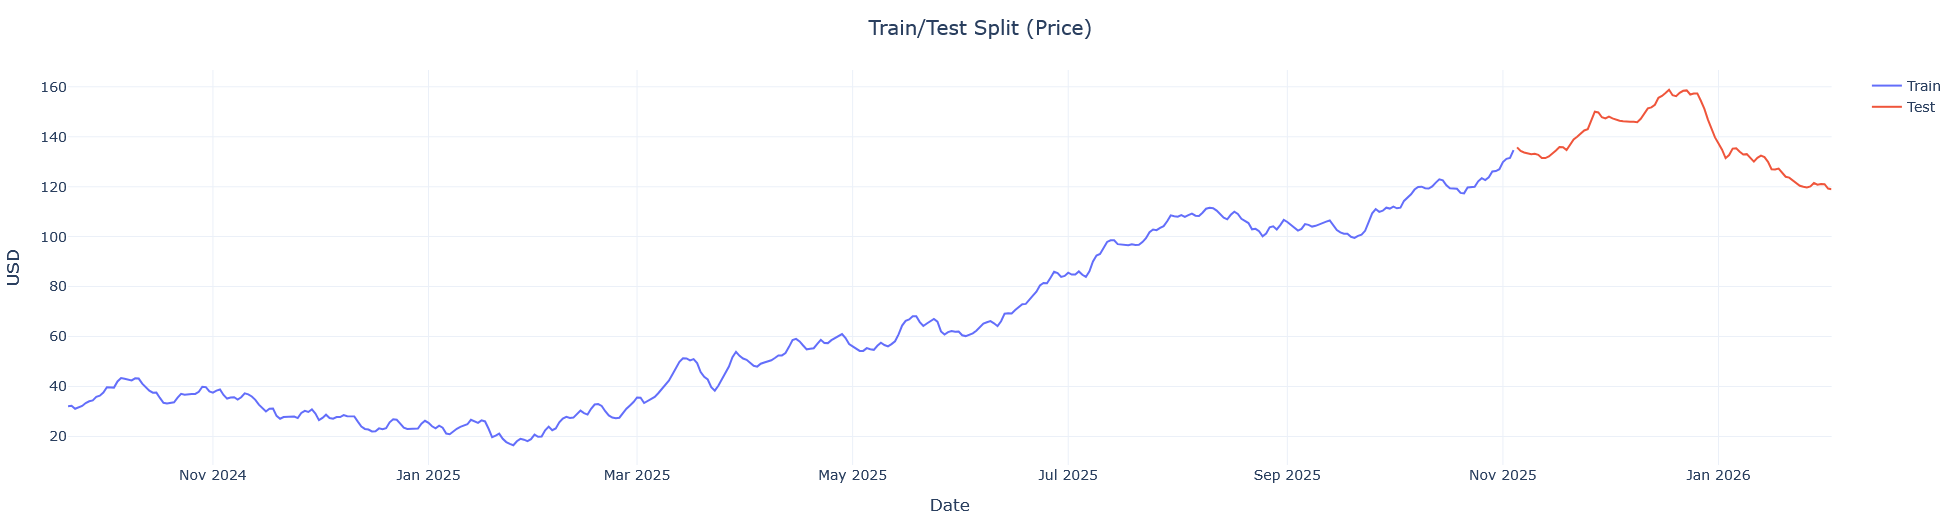

## **Differencing Helpers (d=0,1,2)**

Since, ARMA assumes stationarity, I did differencing on the price series $d$ times before fitting. I also needed a correct inverse step to reconstruct forecasts back to price levels.

In [ ]:
def difference(level, d: int):
    """
    Apply d-th order differencing to a level series (d = 0, 1, or 2)
    """
    level = np.asarray(level, float)
    out = level.copy()
    for _ in range(d):
        out = np.diff(out)
    return out

def invert_from_level(prev_levels, d: int, stat_pred):
    """
    Convert a one-step forecast from the differenced space back to the original level scale
    """
    stat_pred = float(stat_pred)
    if d == 0:
        return stat_pred
    if d == 1:
        return prev_levels[-1] + stat_pred
    if d == 2:
        return 2*prev_levels[-1] - prev_levels[-2] + stat_pred
    raise ValueError("d must be 0,1,2")

def seed_for_future(level, d: int):
    """
    Build the minimal last-level seed needed to invert a multi-step forecast for differencing order d
    """
    level = np.asarray(level, float)
    if d == 0:
        return {"y1": level[-1]}
    if d == 1:
        return {"y1": level[-1]}
    if d == 2:
        return {"y2": level[-2], "y1": level[-1]}
    raise ValueError("d must be 0,1,2")

def invert_future(stat_forecast, seed, d: int):
    """
    Invert a multi-step forecast from differenced space back to level space using a provided seed
    """
    stat_forecast = np.asarray(stat_forecast, float)
    if d == 0:
        return stat_forecast
    if d == 1:
        return seed["y1"] + np.cumsum(stat_forecast)
    if d == 2:
        y2, y1 = seed["y2"], seed["y1"]
        out = np.zeros(len(stat_forecast), float)
        for t in range(len(stat_forecast)):
            out[t] = 2*y1 - y2 + stat_forecast[t]
            y2, y1 = y1, out[t]
        return out
    raise ValueError("d must be 0,1,2")

## **ARMA recursion core**

For given parameters, $c,ϕ,θ$, it computes residuals and fitted values by iterating forward in time.

In [ ]:
if NUMBA_OK:
    @njit
    def arma_sse_only(y, c, phi, theta, burn):
        """
        Compute ARMA residual SSE after a burn-in period (Numba-accelerated)
        """
        n = y.shape[0]
        p = phi.shape[0]
        q = theta.shape[0]
        e = np.zeros(n)
        sse = 0.0
        m = 0

        for t in range(n):
            ar_part = 0.0
            for i in range(1, p+1):
                if t-i >= 0:
                    ar_part += phi[i-1] * y[t-i]

            ma_part = 0.0
            for j in range(1, q+1):
                if t-j >= 0:
                    ma_part += theta[j-1] * e[t-j]

            et = y[t] - (c + ar_part + ma_part)
            e[t] = et

            if t >= burn:
                sse += et*et
                m += 1

        return sse, m

    @njit
    def arma_filter(y, c, phi, theta):
        """
        Run the ARMA recursion to return residuals and fitted values (Numba-accelerated)
        """
        n = y.shape[0]
        p = phi.shape[0]
        q = theta.shape[0]
        e = np.zeros(n)
        yhat = np.zeros(n)

        for t in range(n):
            ar_part = 0.0
            for i in range(1, p+1):
                if t-i >= 0:
                    ar_part += phi[i-1] * y[t-i]

            ma_part = 0.0
            for j in range(1, q+1):
                if t-j >= 0:
                    ma_part += theta[j-1] * e[t-j]

            yhat[t] = c + ar_part + ma_part
            e[t] = y[t] - yhat[t]

        return e, yhat
else:
    def arma_sse_only(y, c, phi, theta, burn):
        """
        Compute ARMA residual SSE after a burn-in period
        """
        y = np.asarray(y, float)
        p, q = len(phi), len(theta)
        e = np.zeros(len(y), float)
        sse = 0.0
        m = 0
        for t in range(len(y)):
            ar = sum(phi[i-1]*y[t-i] for i in range(1, p+1) if t-i >= 0)
            ma = sum(theta[j-1]*e[t-j] for j in range(1, q+1) if t-j >= 0)
            et = y[t] - (c + ar + ma)
            e[t] = et
            if t >= burn:
                sse += et*et
                m += 1
        return sse, m

    def arma_filter(y, c, phi, theta):
        """
        Run the ARMA recursion to return residuals and fitted values
        """
        y = np.asarray(y, float)
        p, q = len(phi), len(theta)
        e = np.zeros(len(y), float)
        yhat = np.zeros(len(y), float)
        for t in range(len(y)):
            ar = sum(phi[i-1]*y[t-i] for i in range(1, p+1) if t-i >= 0)
            ma = sum(theta[j-1]*e[t-j] for j in range(1, q+1) if t-j >= 0)
            yhat[t] = c + ar + ma
            e[t] = y[t] - yhat[t]
        return e, yhat

## **Fitting ARMA with Conditional sum of squares(CSS)**

I estimated parameters by minimising the sum of squared residuals. It’s not the full exact MLE, but it’s stable enough for a grid search.

In [ ]:
def fit_arma_css(y_stat, p: int, q: int, include_c: bool, maxiter=60):
    """
    Fit ARMA(p,q) by minimizing conditional SSE (CSS) and return parameters plus AIC
    """
    y_stat = np.asarray(y_stat, float)
    burn = max(p, q)

    if include_c:
        x0 = np.zeros(1 + p + q)
        x0[0] = float(np.mean(y_stat))
        bounds = [(None, None)] + [(-0.99, 0.99)]*p + [(-0.99, 0.99)]*q
    else:
        x0 = np.zeros(p + q)
        bounds = [(-0.99, 0.99)]*p + [(-0.99, 0.99)]*q

    def unpack(x):
        if include_c:
            c = float(x[0])
            phi = x[1:1+p]
            theta = x[1+p:1+p+q]
        else:
            c = 0.0
            phi = x[:p]
            theta = x[p:p+q]
        return c, phi.astype(float), theta.astype(float)

    def obj(x):
        c, phi, theta = unpack(x)
        sse, _ = arma_sse_only(y_stat, c, phi, theta, burn)
        return float(sse)

    res = minimize(obj, x0, method="L-BFGS-B", bounds=bounds,
                   options={"maxiter": maxiter, "ftol": 1e-6})

    c, phi, theta = unpack(res.x)
    sse, m = arma_sse_only(y_stat, c, phi, theta, burn)
    sigma2 = (sse / m) if m > 0 else np.nan
    ll = -0.5 * m * (np.log(2*np.pi*sigma2) + 1) if sigma2 > 0 else -np.inf

    k = (len(res.x) + 1)
    aic = 2*k - 2*ll

    return {
        "success": bool(res.success),
        "c": c, "phi": phi, "theta": theta,
        "sigma2": float(sigma2),
        "aic": float(aic),
        "burn": burn
    }

def fit_full(y_stat, p, q, include_c, maxiter=400):
    """
    Fit ARMA(p,q) via CSS and return fitted values and residuals
    """
    fit = fit_arma_css(y_stat, p, q, include_c, maxiter=maxiter)
    e, yhat = arma_filter(np.asarray(y_stat, float), fit["c"], fit["phi"], fit["theta"])
    burn = fit["burn"]
    fit["resid_full"] = e
    fit["fitted_full"] = yhat
    fit["resid_used"] = e[burn:] if burn > 0 else e
    return fit

## **Full grid search over $p,d,q$ using AIC**

In [ ]:
y_train_arr = y_train.values.astype(float)
diff_cache = {d: difference(y_train_arr, d) for d in range(D_MAX+1)}

orders = [(p, d, q) for d in range(D_MAX+1)
                  for p in range(P_MAX+1)
                  for q in range(Q_MAX+1)]

def fit_one(order):
    """
    Fit one (p,d,q) candidate with CSS and return its AIC and convergence flag for grid search
    """
    p, d, q = order
    include_c = (d == 0)
    try:
        y_stat = diff_cache[d]
        fit = fit_arma_css(y_stat, p, q, include_c, maxiter=MAXITER_GRID)
        return (p, d, q, fit["aic"], fit["success"])
    except Exception:
        return (p, d, q, np.inf, False)

grid = Parallel(n_jobs=N_JOBS, backend="loky")(delayed(fit_one)(o) for o in orders)

res = pd.DataFrame(grid, columns=["p","d","q","aic","converged"])
res = res.replace([np.inf, -np.inf], np.nan).dropna(subset=["aic"])
best = res.query("converged == True").sort_values("aic").iloc[0]

best_p, best_d, best_q = int(best.p), int(best.d), int(best.q)
print("Best (p,d,q):", (best_p, best_d, best_q), "| AIC:", float(best.aic))

Best (p,d,q): (8, 2, 2) | AIC: 1131.3713581060586


The grid preferred a second-difference model with a high AR order

## **AIC Heatmap for the chosen $d$**

In [ ]:
sub = res.query("d == @best_d and converged == True")
pivot = sub.pivot(index="p", columns="q", values="aic")

fill_val = np.nanmax(pivot.values) + 20
pivot_filled = pivot.fillna(fill_val)

fig = px.imshow(
    pivot_filled.values,
    x=pivot_filled.columns.astype(int),
    y=pivot_filled.index.astype(int),
    aspect="auto",
    labels=dict(x="q", y="p", color="AIC"),
    title=f"AIC surface for d={best_d} (lower is better)"
)
fig.update_layout(template="plotly_white", title=dict(x=0.5),
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

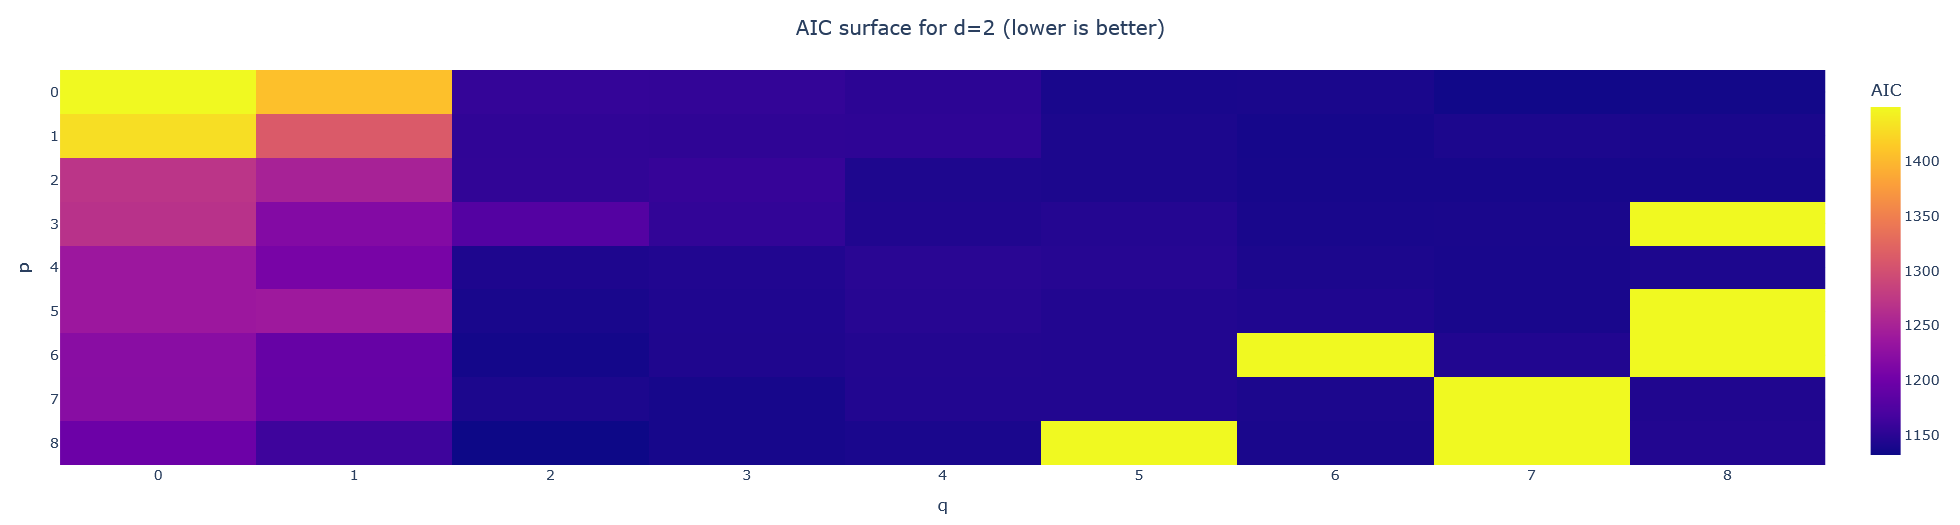

For $d$=2, there is a clear low region and the winner sits inside it. Some cells are missing because not every optimisation converges, but the overall surface still supports the choice.

## **Re-fitting the best model**

In [ ]:
include_c_best = (best_d == 0)
y_train_stat = diff_cache[best_d]
fit_best = fit_full(y_train_stat, best_p, best_q, include_c_best, maxiter=MAXITER_REFIT)

print("Converged:", fit_best["success"])
print("AIC:", fit_best["aic"])

Converged: True
AIC: 1131.3713581060586


The best model refit converged successfully and kept the same AIC value.

## **Residual Diagnostics**

In [ ]:
resid = fit_best["resid_used"]

fig = px.histogram(resid, nbins=60, histnorm="probability density",
                   title="Residual distribution (train, after burn-in)")
fig.update_layout(template="plotly_white", title=dict(x=0.5),
                  xaxis_title="Residual", yaxis_title="Density",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

vals = acf(resid, nlags=40, fft=True)
lags = np.arange(len(vals))
conf = 1.96 / np.sqrt(len(resid))

fig = go.Figure()
fig.add_trace(go.Bar(x=lags, y=vals, name="ACF"))
fig.add_trace(go.Scatter(x=lags, y=[conf]*len(lags), mode="lines",
                         line=dict(dash="dash", width=2), name="95% bound"))
fig.add_trace(go.Scatter(x=lags, y=[-conf]*len(lags), mode="lines",
                         line=dict(dash="dash", width=2), showlegend=False))
fig.update_layout(template="plotly_white",
                  title=dict(text="Residual ACF (train)", x=0.5),
                  xaxis_title="Lag", yaxis_title="ACF",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

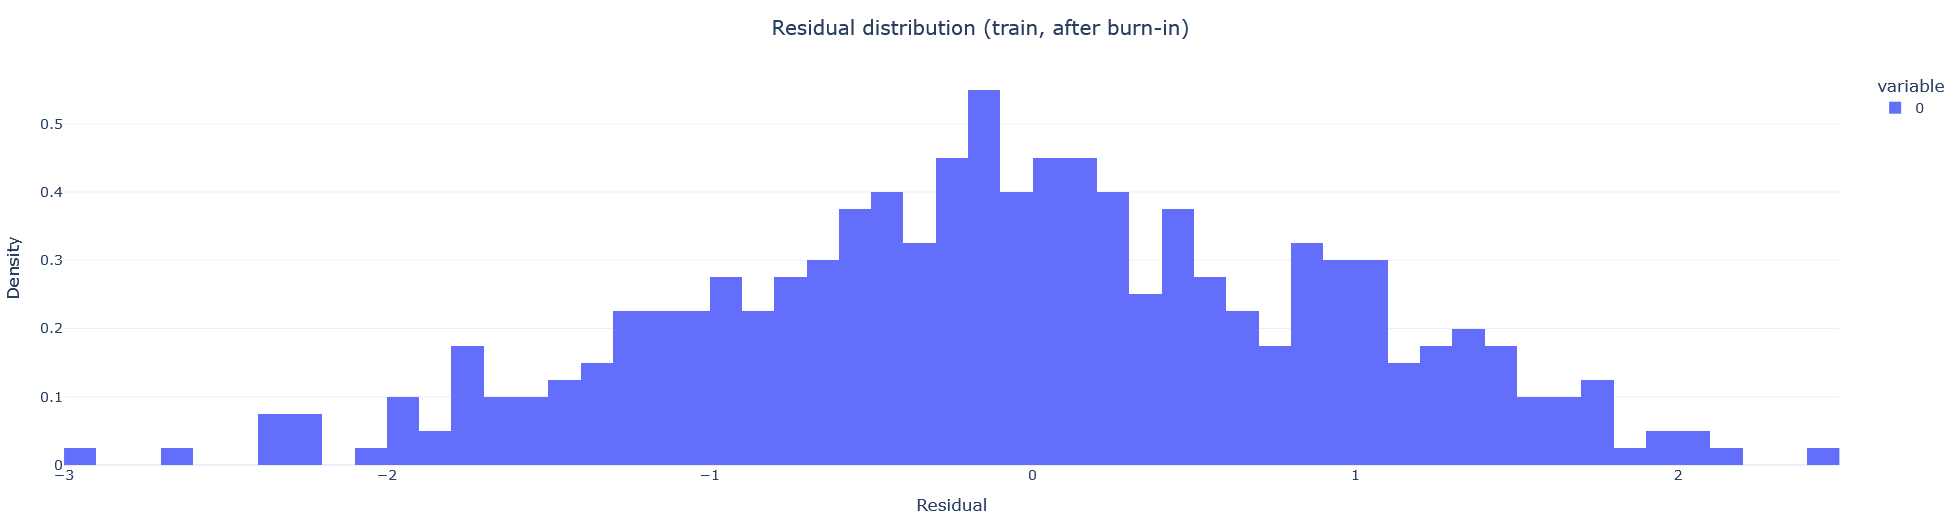

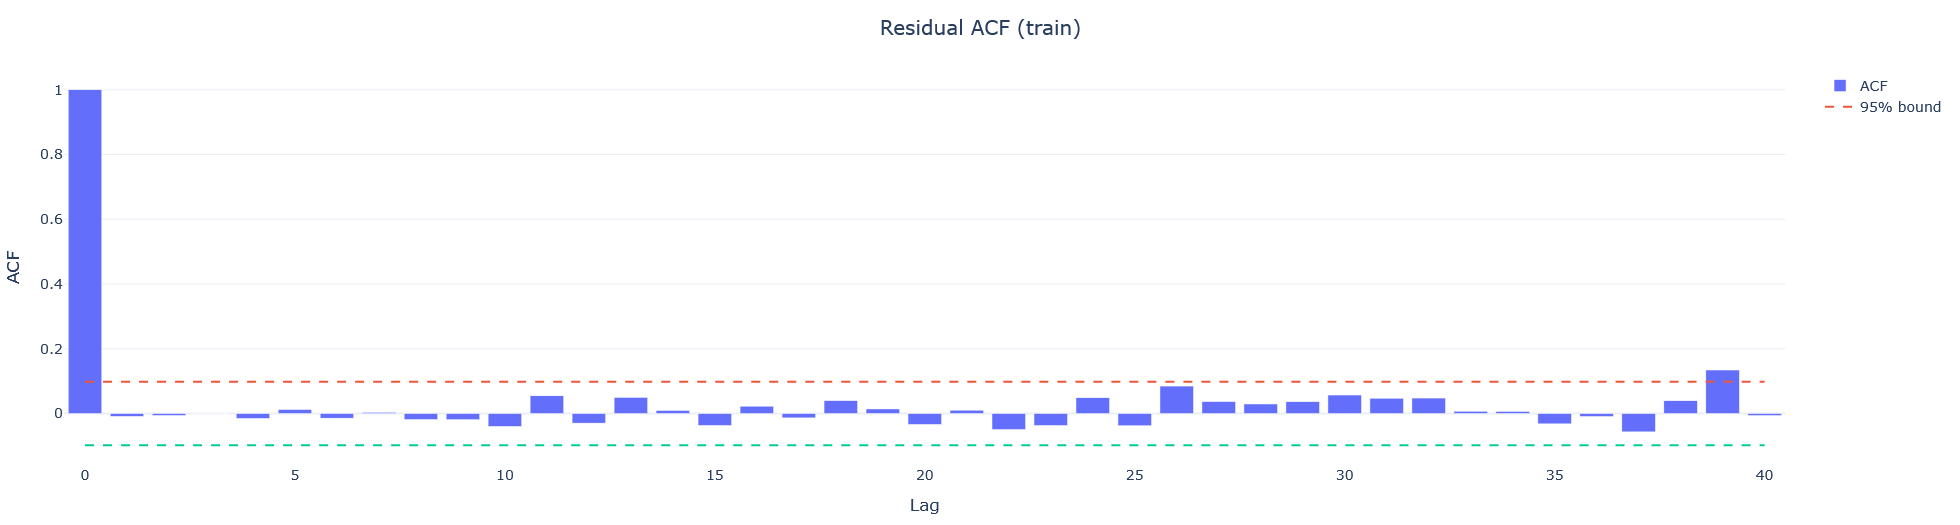

The residual distribution is centred near zero and looks roughly bell-shaped, but not perfectly Gaussian. The residual ACF is basically flat, with almost everything inside the bounds, which seems good.

## **Ljung–Box test on residuals**

This tests whether residual autocorrelation remains up to a given lag. High p-values mean I do not see evidence of leftover autocorrelation.

In [ ]:
lb = acorr_ljungbox(resid, lags=[10,20,30], return_df=True)
lb.columns = ["lb_stat", "lb_pvalue"]
lb

,lb_stat,lb_pvalue
10,1.245629,0.999533
20,6.011392,0.998882
30,15.355411,0.987571


Upto 30 lags, the residuals look uncorrelated, which means the ARMA has removed most of the linear structure from the stationary series.

## **Rolling 1-step evaluation**

I made this plot to see the baseline performance. If the forecast line hugs the test line, the short-horizon dynamics are captured well.

In [ ]:
level_full = np.concatenate([y_train.values, y_test.values])
full_stat = difference(level_full, best_d)
e_full, yhat_full = arma_filter(full_stat, fit_best["c"], fit_best["phi"], fit_best["theta"])
train_stat_len = len(y_train) - best_d
test_start = train_stat_len
test_end = test_start + len(y_test)
yhat_stat_test = yhat_full[test_start:test_end]

pred_level = np.zeros(len(y_test), float)
for k in range(len(y_test)):
    idx_level = len(y_train) + k
    if best_d == 0:
        pred_level[k] = yhat_stat_test[k]
    elif best_d == 1:
        pred_level[k] = level_full[idx_level - 1] + yhat_stat_test[k]
    else:
        pred_level[k] = 2*level_full[idx_level - 1] - level_full[idx_level - 2] + yhat_stat_test[k]

rmse_1step = float(np.sqrt(mean_squared_error(y_test.values, pred_level)))
print("Test RMSE (rolling 1-step):", rmse_1step)

Test RMSE (rolling 1-step): 1.181471878499708


In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y_train.index, y=y_train.values, name="Train", line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index,  y=y_test.values,  name="Test",  line=dict(width=2)))
fig.add_trace(go.Scatter(x=y_test.index,  y=pred_level,      name="1-step forecast", line=dict(width=2)))

fig.update_layout(template="plotly_white",
                  title=dict(text=f"ARMA-from-scratch (p,d,q)={best_p,best_d,best_q} — rolling 1-step test", x=0.5),
                  xaxis_title="Date", yaxis_title="USD",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

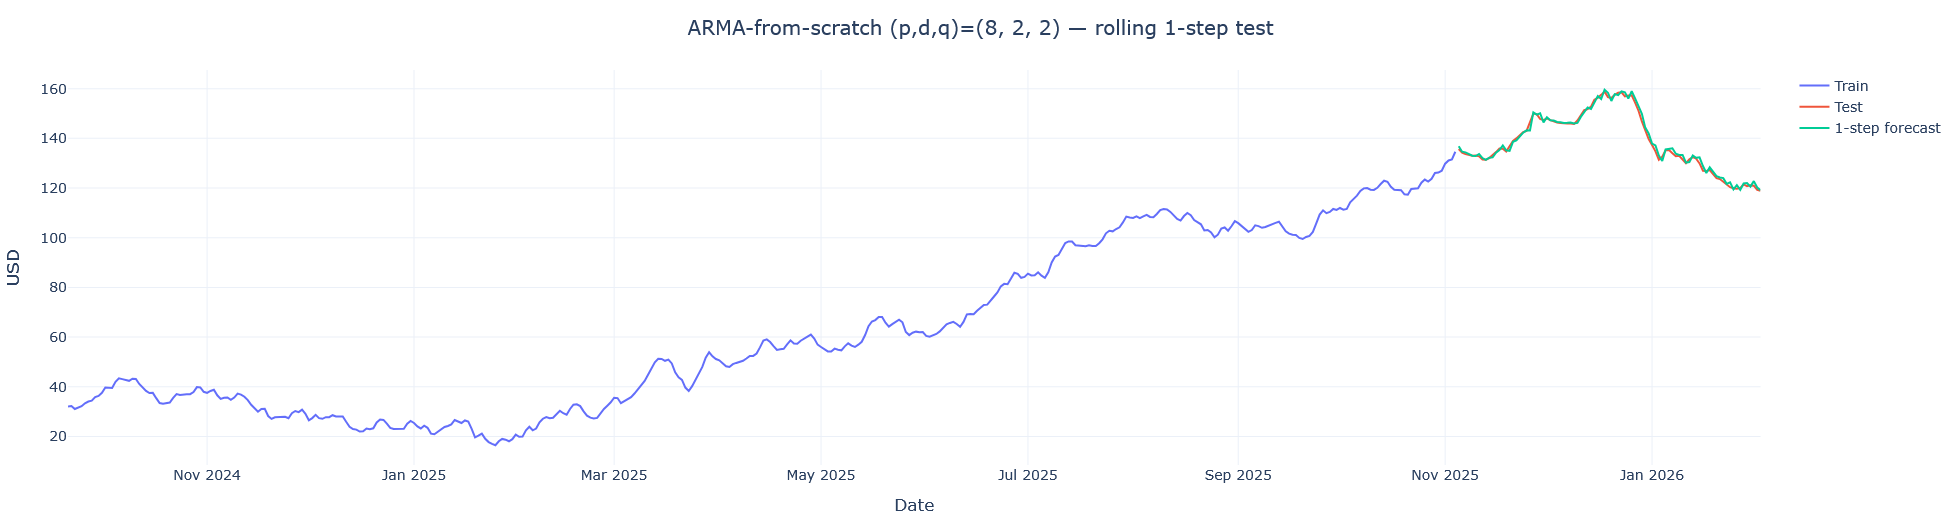

The forecast line follows the test series tightly over most of the window. The model is doing a good job at short-horizon movement.

## **Refitting on the full data for 24-month forecast**

In [ ]:
y_all = y.values.astype(float)
y_all_stat = difference(y_all, best_d)
fit_full_all = fit_full(y_all_stat, best_p, best_q, include_c_best, maxiter=MAXITER_REFIT)
print("Full fit converged:", fit_full_all["success"], "| AIC:", fit_full_all["aic"])

Full fit converged: True | AIC: 1409.113256031942


The AIC is not directly comparable to the train AIC because the sample length changed, but convergence is what matters here.

## **Creating the 24-month forecast horizon**

In [ ]:
fc_start = y.index.max() + pd.Timedelta(days=1)
fc_end   = y.index.max() + pd.DateOffset(months=24)
fc_dates = pd.date_range(fc_start, fc_end, freq="D")
Hf = len(fc_dates)

## **Mean forecast and inversion back to price**

I forecasted forward in the stationary space and then inverted the differencing to get back to price levels.

In [ ]:
def arma_forecast_mean(y_hist, e_hist, c, phi, theta, steps):
    """
    Generate multi-step ARMA mean forecasts in the stationary space
    """
    y_hist = np.asarray(y_hist, float)
    e_hist = np.asarray(e_hist, float)
    phi = np.asarray(phi, float)
    theta = np.asarray(theta, float)
    p, q = len(phi), len(theta)

    y_ext = np.concatenate([y_hist, np.zeros(steps)])
    e_ext = np.concatenate([e_hist, np.zeros(steps)])
    n = len(y_hist)

    for h in range(steps):
        t = n + h
        ar_part = 0.0
        for i in range(1, p+1):
            ar_part += phi[i-1] * y_ext[t-i]
        ma_part = 0.0
        for j in range(1, q+1):
            ma_part += theta[j-1] * e_ext[t-j]
        y_ext[t] = c + ar_part + ma_part
        e_ext[t] = 0.0

    return y_ext[n:]

mean_stat_future = arma_forecast_mean(
    y_hist=y_all_stat,
    e_hist=fit_full_all["resid_full"],
    c=fit_full_all["c"], phi=fit_full_all["phi"], theta=fit_full_all["theta"],
    steps=Hf
)

seed = seed_for_future(y_all, best_d)
mean_level_future = invert_future(mean_stat_future, seed, best_d)

## **Monte Carlo confidence intervals**

To get a 95% confidence interval, I simulated many future paths by adding random shocks based on the fitted innovation variance. Then I took the 2.5% and 97.5% quantiles across paths.

In [ ]:
def simulate_paths(y_hist, e_hist, c, phi, theta, sigma2, steps, n_sims=400, seed=42):
    """
    Simulate ARMA paths in the stationary space by drawing Gaussian shocks and rolling the recursion forward
    """
    rng = np.random.default_rng(seed)
    y_hist = np.asarray(y_hist, float)
    e_hist = np.asarray(e_hist, float)
    phi = np.asarray(phi, float)
    theta = np.asarray(theta, float)
    p, q = len(phi), len(theta)

    n = len(y_hist)
    paths = np.zeros((n_sims, steps), float)

    for s in range(n_sims):
        y_ext = np.concatenate([y_hist, np.zeros(steps)])
        e_ext = np.concatenate([e_hist, np.zeros(steps)])

        for h in range(steps):
            t = n + h
            ar_part = 0.0
            for i in range(1, p+1):
                ar_part += phi[i-1] * y_ext[t-i]
            ma_part = 0.0
            for j in range(1, q+1):
                ma_part += theta[j-1] * e_ext[t-j]

            shock = rng.normal(0.0, np.sqrt(sigma2))
            y_ext[t] = c + ar_part + ma_part + shock
            e_ext[t] = shock

        paths[s] = y_ext[n:]
    return paths

paths_stat = simulate_paths(
    y_hist=y_all_stat,
    e_hist=fit_full_all["resid_full"],
    c=fit_full_all["c"], phi=fit_full_all["phi"], theta=fit_full_all["theta"],
    sigma2=fit_full_all["sigma2"],
    steps=Hf, n_sims=N_SIMS
)

paths_level = np.vstack([invert_future(paths_stat[i], seed, best_d) for i in range(paths_stat.shape[0])])
lower = np.quantile(paths_level, 0.025, axis=0)
upper = np.quantile(paths_level, 0.975, axis=0)

## **Plotting the 24-month forecast with 95% CI**

In [ ]:
fig = go.Figure()
fig.add_trace(go.Scatter(x=y.index, y=y.values, name="Historical", line=dict(width=2)))
fig.add_trace(go.Scatter(x=fc_dates, y=upper, line=dict(width=0), showlegend=False))
fig.add_trace(go.Scatter(x=fc_dates, y=lower, fill="tonexty", name="95% CI", line=dict(width=0)))
fig.add_trace(go.Scatter(x=fc_dates, y=mean_level_future, name="Forecast (mean)", line=dict(width=2)))

fig.update_layout(template="plotly_white",
                  title=dict(text="ARMA-from-scratch: 24-month forecast + 95% CI", x=0.5),
                  xaxis_title="Date", yaxis_title="USD",
                  font=dict(size=14), margin=dict(l=60, r=30, t=70, b=60))
fig.show()

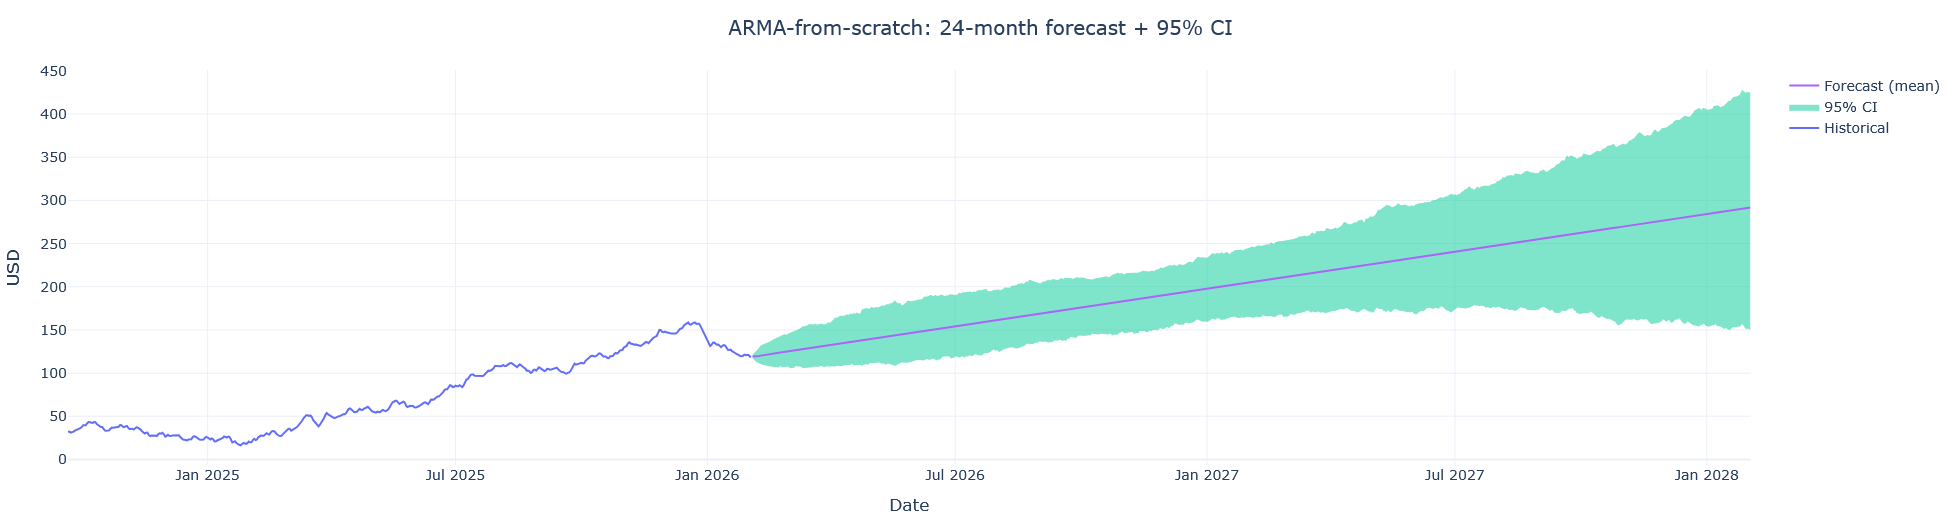

The interval widens over time, which is expected because uncertainty accumulates with horizon. The mean forecast trends upward here because second differencing plus fitted dynamics can create long-run curvature when inverted.

## **Saving the fitted model**

I saved the chosen order and fitted parameters so I can reuse them later for comparison and maybe for deployment.

In [ ]:
out_dir = Path("../models")
out_dir.mkdir(parents=True, exist_ok=True)

payload = {
    "order": (best_p, best_d, best_q),
    "include_c": include_c_best,
    "fit": {
        "c": fit_full_all["c"],
        "phi": fit_full_all["phi"],
        "theta": fit_full_all["theta"],
        "sigma2": fit_full_all["sigma2"],
        "aic": fit_full_all["aic"],
    },
    "rmse_rolling_1step": rmse_1step,
    "last_date": str(y.index.max().date()),
}

with open(out_dir / "arma_params.pkl", "wb") as f:
    pickle.dump(payload, f)

print("Saved:", out_dir / "arma_params.pkl")

Saved: ../models/arma_params.pkl
